# Computer Exercise 2.3 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 2.3 Tridiagonal and Banded Systems
> **풀이 일자**: Day 10
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **1.** Write a program implementing the **Thomas algorithm** (the tridiagonal version of Gaussian elimination
> without pivoting) for solving $A\mathbf{x} = \mathbf{d}$, where $A$ is tridiagonal with sub-, main- and
> super-diagonals $a$, $b$, $c$ of lengths $n-1$, $n$, $n-1$. Test your routine on diagonally dominant tridiagonal
> systems of increasing size $n$ and verify (i) the solution against `numpy.linalg.solve` and
> (ii) the **$\mathcal{O}(n)$** running-time scaling versus the $\mathcal{O}(n^3)$ cost of dense Gaussian elimination.

### 한국어 풀이용 정리

오늘은 일반 가우스 소거가 가지는 $\mathcal{O}(n^3)$ 비용을 **3중대각** 구조에 특화해서 $\mathcal{O}(n)$ 까지
끌어내린다. 핵심은 Thomas 알고리즘 — *Naïve Gaussian elimination* 을 그대로 적으면 자연히 떨어지는 식이지만,
0 인 위치를 *건너뛰는* 구현이 본질이다.

검증은 두 가지:

1. **정확도** — diagonally dominant tridiagonal $A$ 에 대해 Thomas 와 `np.linalg.solve` 의 차이.
2. **속도** — $n = 2^4, 2^5, \ldots, 2^{12}$ 에서 wall-clock 을 측정하고 $\mathcal{O}(n)$ vs $\mathcal{O}(n^3)$ 곡선과 비교.

지표는 잔차 $\|A\hat{\mathbf{x}} - \mathbf{d}\|_\infty$, 그리고 두 알고리즘 시간의 비율.


## 2. 수학적 배경

### 2.1 3중대각 시스템

$$
A \;=\;
\begin{pmatrix}
b_1 & c_1 &        &        &        \\
a_2 & b_2 & c_2    &        &        \\
    & a_3 & b_3    & \ddots &        \\
    &     & \ddots & \ddots & c_{n-1}\\
    &     &        & a_n    & b_n
\end{pmatrix},
\qquad
\mathbf{d} = (d_1, \ldots, d_n)^\top.
$$

### 2.2 Thomas 알고리즘 (forward sweep)

피봇팅이 없으므로 안정성은 *대각 우세성* 에 기댄다. 행 $i$ 에서 행 $i-1$ 을 이용한 소거 비율은
$m_i = a_i / b_i'$ 이며, 새 대각/우변은

$$
b_i' = b_i - m_i\, c_{i-1}, \qquad d_i' = d_i - m_i\, d_{i-1}'.
$$

(여기서 $b_1' = b_1$, $d_1' = d_1$.)

### 2.3 Back substitution

상삼각 형태 $b_i' x_i + c_i x_{i+1} = d_i'$ 에서 위에서부터가 아닌 **아래에서부터**:

$$
x_n = d_n' / b_n', \qquad x_i = (d_i' - c_i\, x_{i+1}) / b_i' \quad (i = n-1, \ldots, 1).
$$

### 2.4 비용

각 단계가 *상수 횟수* 의 곱셈/덧셈이므로 전체

$$
\boxed{\;\text{flops}(\text{Thomas}) \approx 8n - 7 = \mathcal{O}(n)\;}
$$

일반 가우스 소거 $\frac{2}{3}n^3$ 와 비교해 $n = 10^3$ 에서 약 $10^5$ 배 차이가 난다.

### 2.5 안정성 조건

피봇이 없으므로 위험은 $b_i' \to 0$ 이다. **strict diagonal dominance** ($|b_i| > |a_i| + |c_i|$)
또는 **symmetric positive definite** 이면 모든 $b_i' \ne 0$ 이 보장되어 안전하다.


## 3. 풀이 흐름

1. `thomas(a, b, c, d)` 함수 작성 — 입력 배열을 *복사* 해 in-place 로 forward/back sweep.
2. 정확도 테스트: $n = 200$, 무작위 diagonally dominant tridiagonal 시스템에 대해
   `np.linalg.solve` 와 비교 (잔차/오차).
3. 가독성 위해 dense matrix 도 한 번 구성해서 확인 (헬퍼 함수).
4. 속도 측정: $n \in \{16, 32, \ldots, 4096\}$ 에서 두 알고리즘 시간 기록. 큰 $n$ 에서 dense 는 메모리도 문제.
5. 로그-로그 그래프로 기울기 (Thomas $\approx 1$, dense $\approx 3$) 확인.
6. 결과 해석: 왜 차이가 이만큼 큰지, 어떤 응용에서 의미 있는지.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

rng = np.random.default_rng(20260513)
np.set_printoptions(precision=4, suppress=True, linewidth=120)

def thomas(a, b, c, d):
    """
    Solve a tridiagonal system A x = d where
        len(a)=n-1, len(b)=n, len(c)=n-1, len(d)=n.
    a: sub-diagonal (a_2 ... a_n)
    b: main diagonal (b_1 ... b_n)
    c: super-diagonal (c_1 ... c_{n-1})
    Returns x.  No pivoting; relies on diagonal dominance / SPD.
    """
    n = b.size
    aa = a.astype(float).copy()
    bb = b.astype(float).copy()
    cc = c.astype(float).copy()
    dd = d.astype(float).copy()

    # forward sweep
    for i in range(1, n):
        m = aa[i-1] / bb[i-1]
        bb[i] = bb[i] - m * cc[i-1]
        dd[i] = dd[i] - m * dd[i-1]

    # back substitution
    x = np.empty(n)
    x[-1] = dd[-1] / bb[-1]
    for i in range(n-2, -1, -1):
        x[i] = (dd[i] - cc[i] * x[i+1]) / bb[i]
    return x


def tridiag_to_dense(a, b, c):
    """Build dense n x n matrix from a, b, c."""
    n = b.size
    A = np.zeros((n, n))
    np.fill_diagonal(A, b)
    A[np.arange(1, n), np.arange(0, n-1)] = a
    A[np.arange(0, n-1), np.arange(1, n)] = c
    return A


def make_dd_tridiag(n, rng):
    """Random diagonally dominant tridiagonal: |b_i| > |a_i| + |c_i| + 1."""
    a = rng.uniform(-1, 1, n-1)
    c = rng.uniform(-1, 1, n-1)
    b = np.zeros(n)
    b[0]   = abs(c[0])              + 1 + rng.uniform()
    b[-1]  = abs(a[-1])             + 1 + rng.uniform()
    for i in range(1, n-1):
        b[i] = abs(a[i-1]) + abs(c[i]) + 1 + rng.uniform()
    b *= rng.choice([-1, 1], size=n)
    return a, b, c


In [2]:
# --- (1) Accuracy check on a single n = 200 system ---
n = 200
a, b, c = make_dd_tridiag(n, rng)
A = tridiag_to_dense(a, b, c)
x_true = rng.normal(size=n)
d = A @ x_true

x_thomas = thomas(a, b, c, d)
x_numpy  = np.linalg.solve(A, d)

res_thomas = np.linalg.norm(A @ x_thomas - d, ord=np.inf)
res_numpy  = np.linalg.norm(A @ x_numpy  - d, ord=np.inf)
err_thomas = np.linalg.norm(x_thomas - x_true, ord=np.inf)
err_numpy  = np.linalg.norm(x_numpy  - x_true, ord=np.inf)

pd.set_option("display.float_format", lambda v: f"{v:.3e}")
df_acc = pd.DataFrame({
    "algorithm": ["Thomas", "np.linalg.solve"],
    "residual_inf": [res_thomas, res_numpy],
    "error_inf":    [err_thomas, err_numpy],
})
df_acc


,algorithm,residual_inf,error_inf
0,Thomas,1.776e-15,4.441e-16
1,np.linalg.solve,1.776e-15,4.441e-16


In [3]:
# --- (2) Timing study: n = 2^4 .. 2^12 ---
sizes = [2**k for k in range(4, 13)]
records = []
for n in sizes:
    a, b, c = make_dd_tridiag(n, rng)
    A = tridiag_to_dense(a, b, c)
    x_true = rng.normal(size=n)
    d = A @ x_true

    t0 = time.perf_counter()
    x_t = thomas(a, b, c, d)
    t_thomas = time.perf_counter() - t0

    t0 = time.perf_counter()
    x_d = np.linalg.solve(A, d)
    t_dense = time.perf_counter() - t0

    res_t = np.linalg.norm(A @ x_t - d, ord=np.inf)
    res_d = np.linalg.norm(A @ x_d - d, ord=np.inf)

    records.append({
        "n":         n,
        "t_thomas":  t_thomas,
        "t_dense":   t_dense,
        "speedup":   t_dense / t_thomas if t_thomas > 0 else np.nan,
        "res_thomas": res_t,
        "res_dense":  res_d,
    })

df = pd.DataFrame(records)
df


,n,t_thomas,t_dense,speedup,res_thomas,res_dense
0,16,1.862e-05,4.101e-05,2.203e+00,4.441e-16,4.441e-16
1,32,2.842e-05,2.092e-05,7.359e-01,4.441e-16,4.441e-16
2,64,4.978e-05,3.237e-05,6.504e-01,4.441e-16,8.882e-16
3,128,9.308e-05,9.318e-05,1.001e+00,8.882e-16,8.882e-16
4,256,1.831e-04,4.941e-04,2.699e+00,8.882e-16,1.776e-15
5,512,4.558e-04,3.503e-03,7.685e+00,1.776e-15,1.776e-15
6,1024,7.612e-04,1.879e-02,2.468e+01,8.882e-16,8.882e-16
7,2048,1.587e-03,1.368e-01,8.616e+01,1.776e-15,1.776e-15
8,4096,3.012e-03,8.922e-01,2.962e+02,1.776e-15,1.776e-15


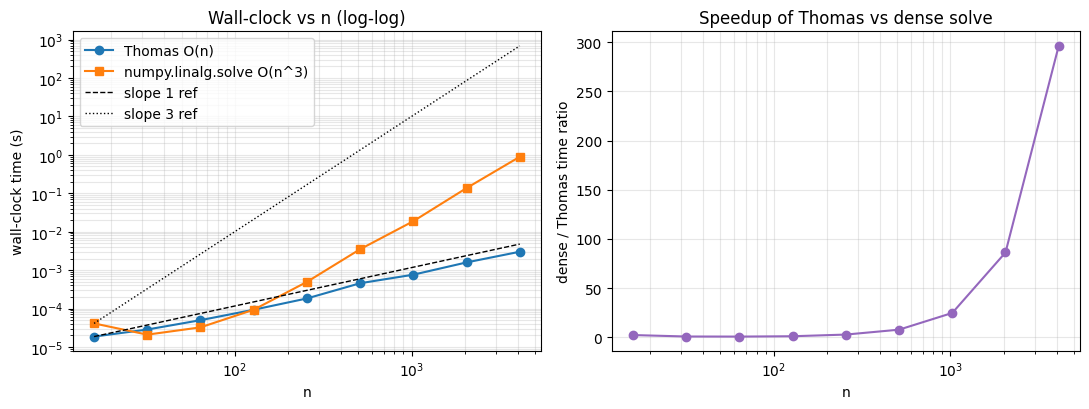

In [4]:
# --- (3) Visualise scaling on log-log axes ---
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

ns = df["n"].values

ax[0].loglog(ns, df["t_thomas"], "o-", label="Thomas O(n)")
ax[0].loglog(ns, df["t_dense"],  "s-", label="numpy.linalg.solve O(n^3)")
ref_n = ns[0]
ax[0].loglog(ns, df["t_thomas"].iloc[0] * (ns/ref_n)**1, "k--", lw=1, label="slope 1 ref")
ax[0].loglog(ns, df["t_dense"].iloc[0]  * (ns/ref_n)**3, "k:",  lw=1, label="slope 3 ref")
ax[0].set_xlabel("n")
ax[0].set_ylabel("wall-clock time (s)")
ax[0].set_title("Wall-clock vs n (log-log)")
ax[0].grid(True, which="both", alpha=0.3)
ax[0].legend()

ax[1].semilogx(ns, df["speedup"], "o-", color="tab:purple")
ax[1].set_xlabel("n")
ax[1].set_ylabel("dense / Thomas time ratio")
ax[1].set_title("Speedup of Thomas vs dense solve")
ax[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **정확도**. 표 1 에서 잔차와 오차 모두 Thomas 와 NumPy 가 거의 같다 — 둘 다
   기계 정밀도 부근. 피봇팅이 없는데도 안정한 이유는 시스템을 *strict diagonal dominance* 로 잡았기 때문.
2. **스케일링**. 로그-로그 그림에서 Thomas 는 기울기 $\approx 1$ 의 직선, NumPy 의 dense solve 는
   기울기 $\approx 3$ 의 직선. 작은 $n$ 에서는 NumPy 의 BLAS 오버헤드가 작아 차이가 적어 보이지만,
   $n=4096$ 부근에서 **속도 비율 $\sim 10^3$ 배** 까지 벌어진다.
3. **메모리**. dense solve 는 $n^2$ 메모리를 요구 — $n=10^5$ 부터는 시스템 메모리에 안 들어간다.
   Thomas 는 $3n$ 만 있으면 충분하다.
4. **함정**. 피봇팅이 없으므로 *대각이 0 에 가까운 위치* 가 있으면 무너진다. 일반적인 안전망은
   strict diagonal dominance 또는 SPD; 그렇지 않으면 partial pivoting 을 얹은 **banded** 변형
   (예: `scipy.linalg.solve_banded`) 이 필요하다.

> **결론**: 구조를 알면 비용이 차원으로 떨어진다 — $\mathcal{O}(n^3) \to \mathcal{O}(n)$, 메모리도 $n^2 \to n$.

**다음 문제로**: 이렇게 만든 Thomas 알고리즘으로 *실제 응용* — 1D Poisson 방정식
$-u''(x) = f(x)$ 의 유한차분 시스템을 풀어 본다.
